# Fixing missing values for weather and consumption data

## Weather data
As shown in previous sections the weather data from metorological-raw is almost completely full. With only a few records missing in humidity, the practical and sufficient solution in this case is to drop the rows with missing values.

In [1]:
import pandas as pd

# Load the raw weather data
weather_path = '../../../data/paraguay/meteorological-raw.csv'
df_weather = pd.read_csv(weather_path)

In [2]:
df_weather.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22445 entries, 0 to 22444
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     22445 non-null  object 
 1   temperature  22445 non-null  float64
 2   humidity     22364 non-null  float64
 3   wind_speed   22444 non-null  float64
 4   pressure     22441 non-null  float64
dtypes: float64(4), object(1)
memory usage: 876.9+ KB


In [3]:
# drop null rows
df_weather_cleaned = df_weather.dropna()
df_weather_cleaned.info()
print("\n")

# change in data set but getting biggest reduction in size
df_weather_reduction = df_weather.shape[0] - df_weather_cleaned.shape[0]
print(f"Rows removed: {df_weather_reduction}")
print(f"Percentage reduction: {df_weather_reduction / df_weather.shape[0] * 100:.2f}%")


<class 'pandas.core.frame.DataFrame'>
Index: 22359 entries, 0 to 22444
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     22359 non-null  object 
 1   temperature  22359 non-null  float64
 2   humidity     22359 non-null  float64
 3   wind_speed   22359 non-null  float64
 4   pressure     22359 non-null  float64
dtypes: float64(4), object(1)
memory usage: 1.0+ MB


Rows removed: 86
Percentage reduction: 0.38%


## Consumption data
As we can see in our exploration we have a few patterens emerging. When a substation feeder does not have data the others feeders within the same substain are more likely to not be on. We also mapped out some correlations across feeder substations and saw that some had a very high correlation. We could utilize this and interpolate the data from one feeder to the other, and vice versa, for the missing values. 

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the raw consumption data
consumption_path = '../../../data/paraguay/electricity-consumption-raw.csv'
df_consumption = pd.read_csv(consumption_path)


# use a list of tuples with pairs of feeders that are highly correlated to fill in missing values using each other's data
pivot_df = df_consumption.pivot_table(index='datetime', columns='feeder', values='consumption')
# Compute the correlation matrix between feeders
corr_matrix = pivot_df.corr()


high_corr_threshold = 0.8
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > high_corr_threshold:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
        
print(f"Highly correlated feeder pairs (correlation > {high_corr_threshold}):")
for pair in high_corr_pairs:
    print(f"{pair[0]} and {pair[1]}: {pair[2]:.2f}")

Highly correlated feeder pairs (correlation > 0.8):
E1 and E4: 0.85
E1 and E7: 0.82
E2 and E4: 0.88
E2 and E7: 0.81
E2 and G1: 0.86
E4 and E7: 0.87
E6 and H5: 0.83
E7 and H3: 0.82
E7 and K1: 0.85
E7 and K2: 0.88


In [19]:
time_cols = [col for col in df_consumption.columns if 'time' in col.lower() or 'date' in col.lower()]
feeder_cols = [col for col in df_consumption.columns if col not in time_cols]

def show_missing_data(df):
    # Identify time and feeder columns

    if time_cols and 'feeder' in df.columns and 'consumption' in df.columns:
        time_col = time_cols[0]
        
        # Convert time column to datetime if not already
        df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
        
        # Create pivot table with consumption values (not feeder names)
        presence = df.pivot(index=time_col, columns='feeder', values='consumption').notna()
        
        plt.figure(figsize=(20, 12))
        # Note: In this visualization, black = data present, white = data missing
        plt.imshow(presence.T, aspect='auto', interpolation='none', cmap='Greys')
        plt.xlabel('Date')
        plt.ylabel('Feeders')
        plt.title('Feeder Data Presence Over Time (white=Missing consumption data, black=Present)')
        
        # Set x-ticks to show dates
        xticks = np.linspace(0, len(presence.index) - 1, min(20, len(presence.index))).astype(int)
        plt.xticks(xticks, [presence.index[i].strftime('%Y-%m-%d') if not pd.isnull(presence.index[i]) else '' for i in xticks], rotation=45, ha='right', fontsize=10)
        plt.yticks(np.arange(len(presence.columns)), presence.columns, fontsize=10)
        plt.gca().set_yticks(np.arange(-0.5, len(presence.columns), 1), minor=True)
        plt.gca().yaxis.grid(True, which='minor', linestyle='-', linewidth=0.5)
        plt.colorbar(label='Data Present')
        plt.tight_layout()
        plt.show()
        
        # Print some statistics about missing data
        missing_stats = presence.mean().sort_values()
        print("\\nFeeder data availability (percentage of time periods with data):")
        for feeder in missing_stats.index[:10]:  # Show 10 worst feeders
            print(f"{feeder}: {missing_stats[feeder]*100:.1f}% available")
        
    else:
        print("Required columns not found for this plot.")


feeder                 A1    A2     B1     B2    B3     B4     B5    B6    C1  \
datetime                                                                        
2017-01-01T01:00:00  58.0  57.0  121.0  146.0  25.0  126.0  156.0  19.0  92.0   
2017-01-01T02:00:00  58.0  57.0  115.0  137.0  35.0  117.0  153.0  18.0  67.0   
2017-01-01T03:00:00  58.0  54.0  115.0  137.0  35.0  117.0  153.0  18.0  85.0   
2017-01-01T04:00:00  52.0  48.0  110.0  142.0  25.0  114.0  143.0  18.0  85.0   
2017-01-01T05:00:00  45.0  42.0  117.0  178.0  25.0  114.0  138.0  18.0  82.0   

feeder                 C2  ...    M2     M3     M4    M5     M6     M7     N1  \
datetime                   ...                                                  
2017-01-01T01:00:00  55.0  ...  54.0  166.0  172.0  96.0  112.0   98.0  179.0   
2017-01-01T02:00:00  55.0  ...  52.0  162.0  192.0  92.0  112.0  100.0  176.0   
2017-01-01T03:00:00  50.0  ...  52.0  162.0  192.0  92.0  112.0  100.0  146.0   
2017-01-01T04:00:00  50.0  

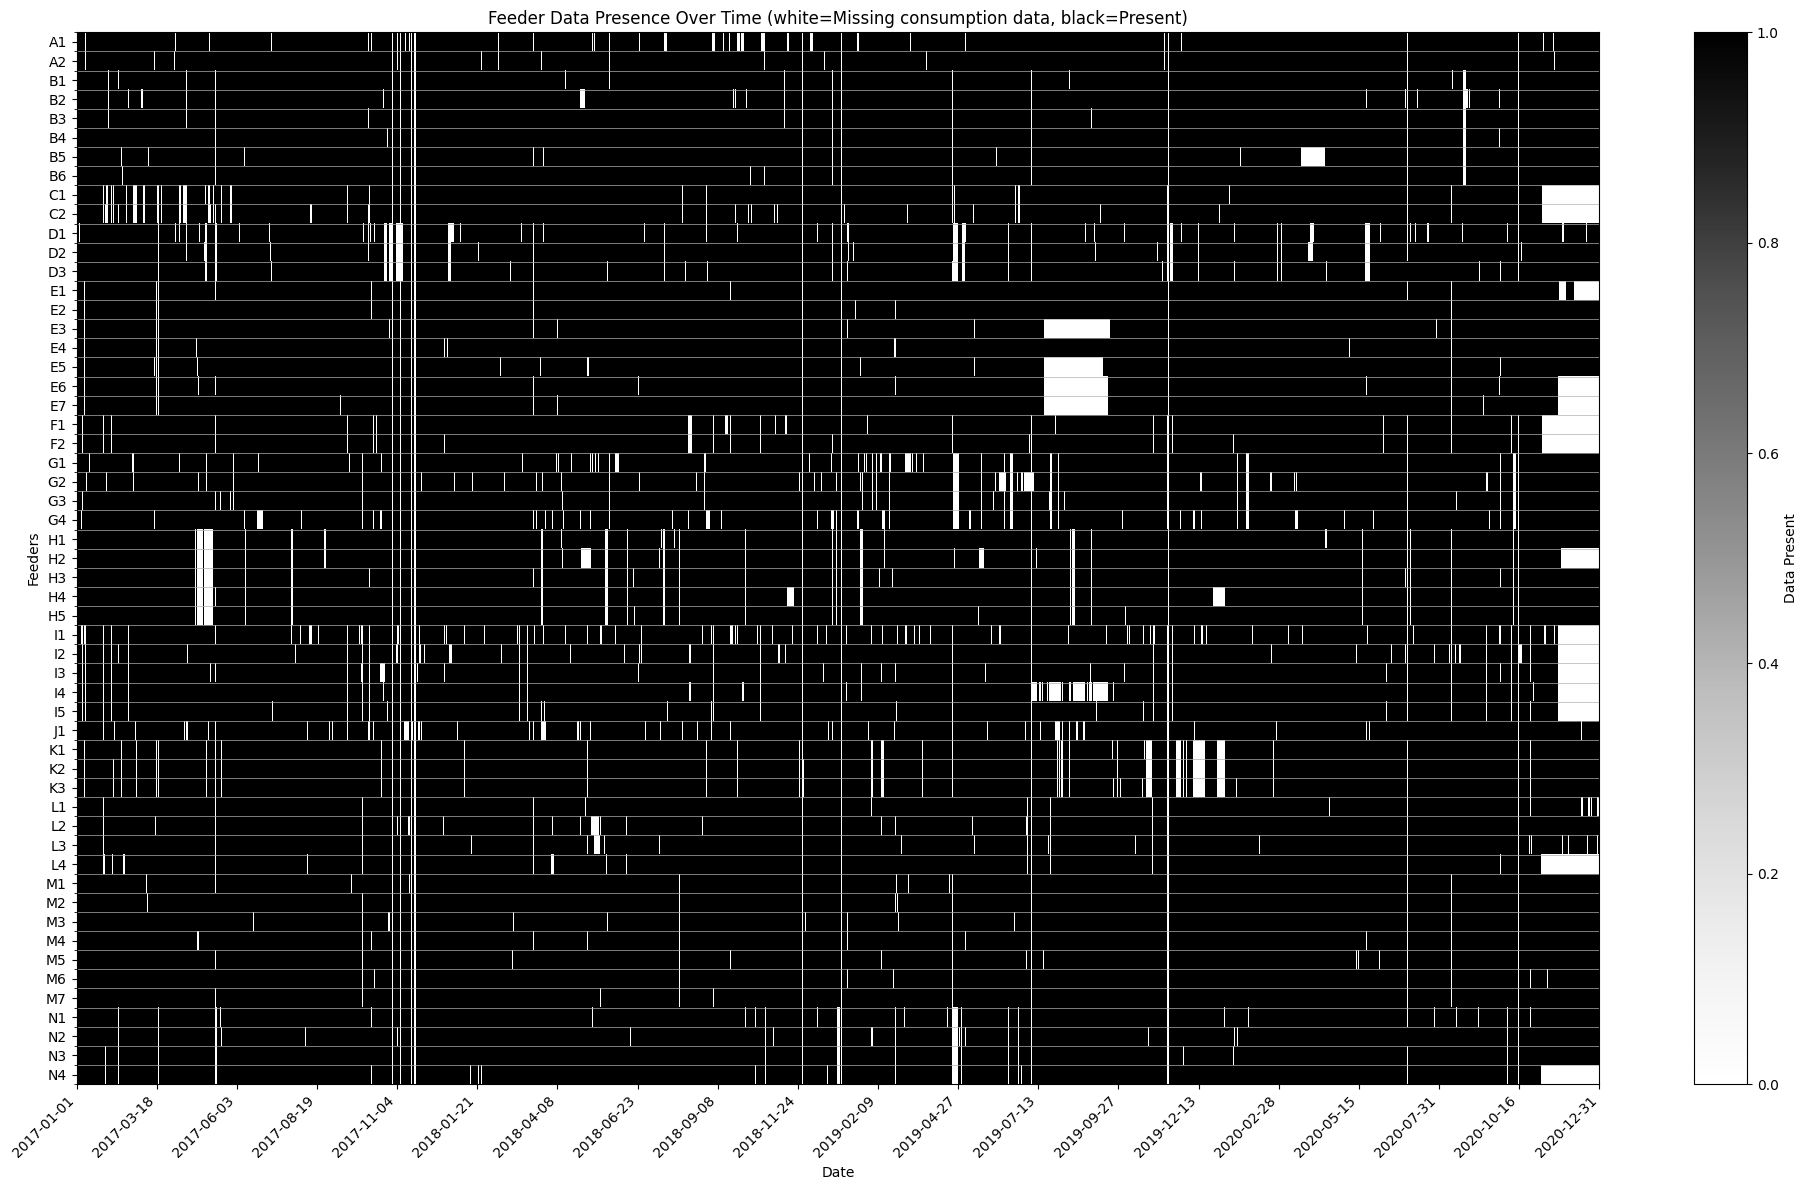

\nFeeder data availability (percentage of time periods with data):
I1: 91.0% available
I4: 91.6% available
E7: 91.8% available
E6: 91.9% available
C2: 92.0% available
H2: 92.5% available
C1: 93.0% available
N4: 93.5% available
I2: 93.7% available
D1: 93.8% available


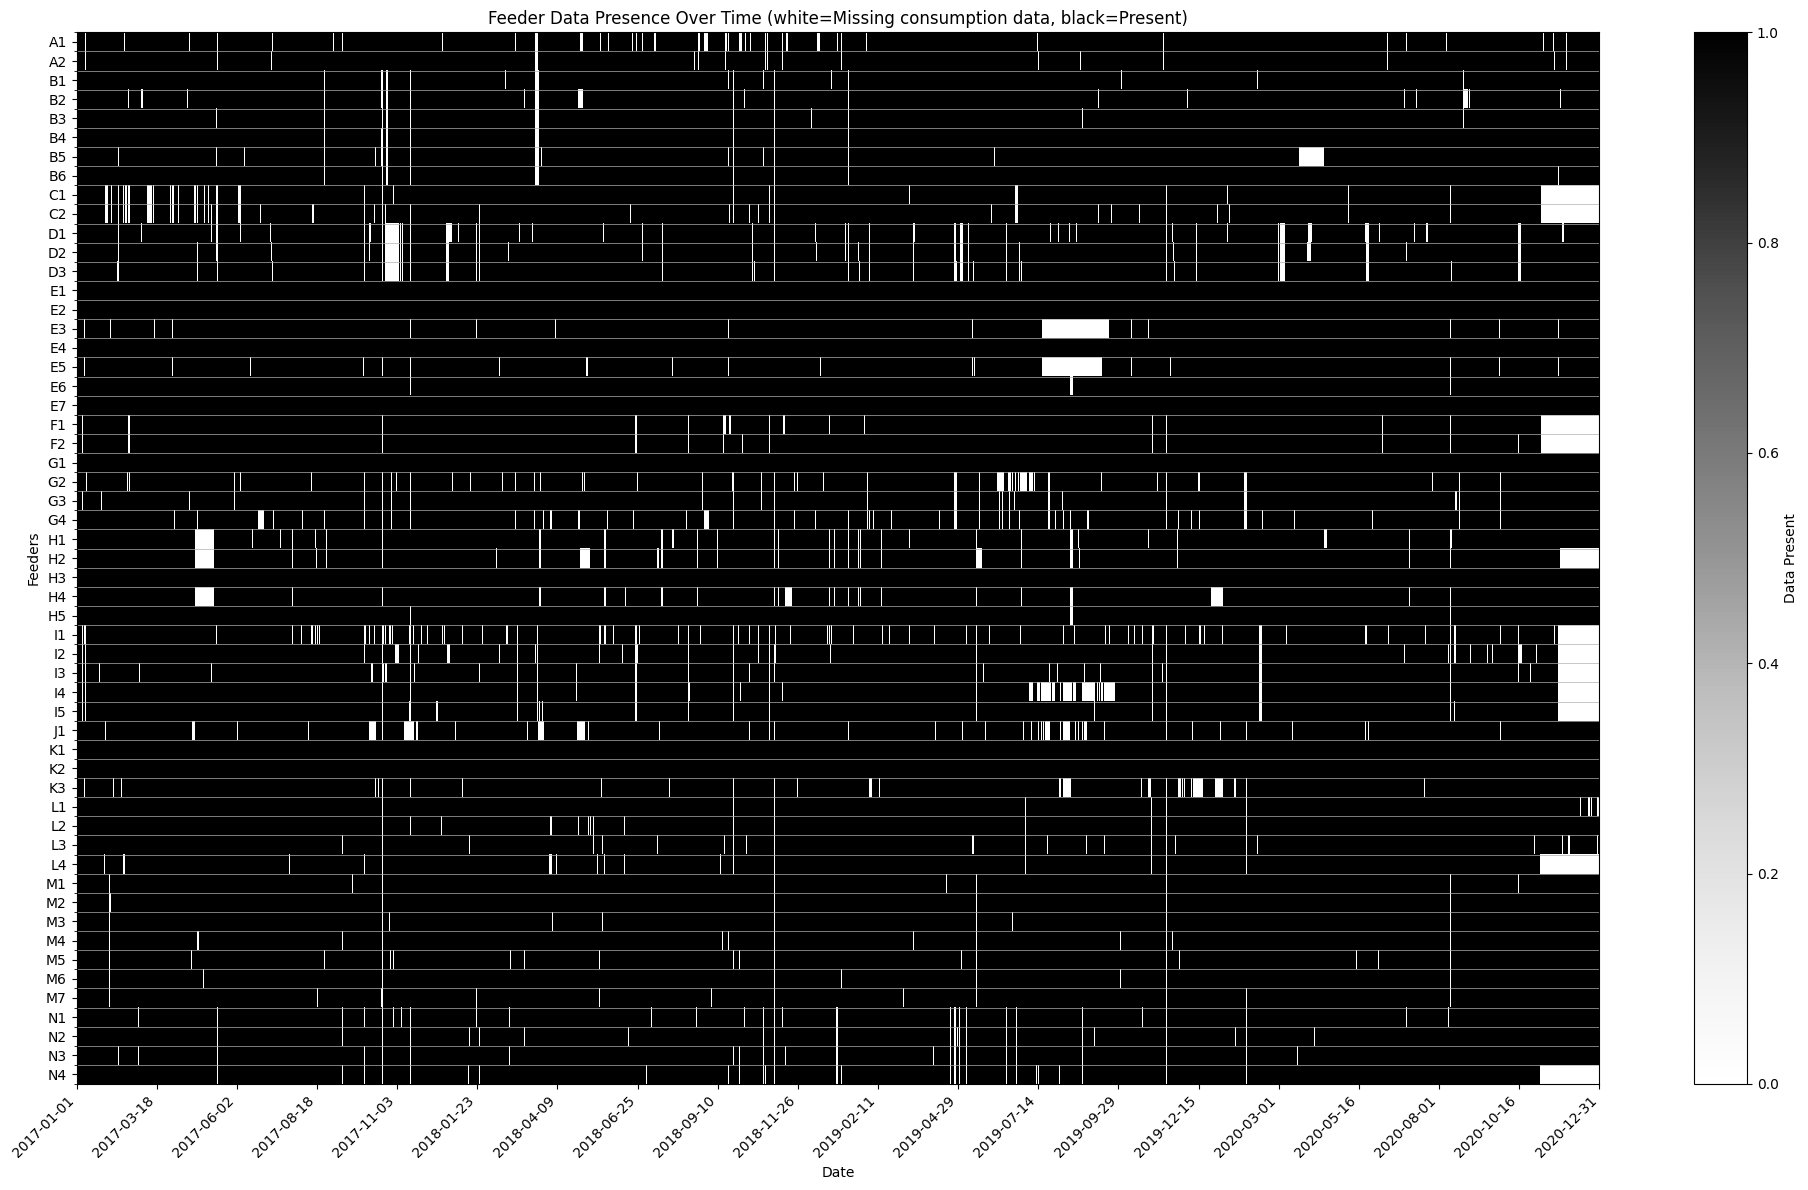

\nFeeder data availability (percentage of time periods with data):
I1: 91.4% available
I4: 92.0% available
C2: 92.5% available
H2: 93.0% available
C1: 93.5% available
N4: 94.0% available
I2: 94.1% available
D1: 94.3% available
J1: 94.4% available
F1: 94.6% available


In [26]:
print(pivot_df.head())


show_missing_data(df_consumption)



# Use the pairs of highly correlated feeders to fill in missing values
for feeder1, feeder2, _ in high_corr_pairs:
    pivot_df[feeder1] = pivot_df[feeder1].fillna(pivot_df[feeder2])
    pivot_df[feeder2] = pivot_df[feeder2].fillna(pivot_df[feeder1])


# Convert back to original long format
df_consumption_filled = pivot_df.reset_index().melt(
    id_vars=['datetime'], 
    var_name='feeder', 
    value_name='consumption'
)

show_missing_data(df_consumption_filled)


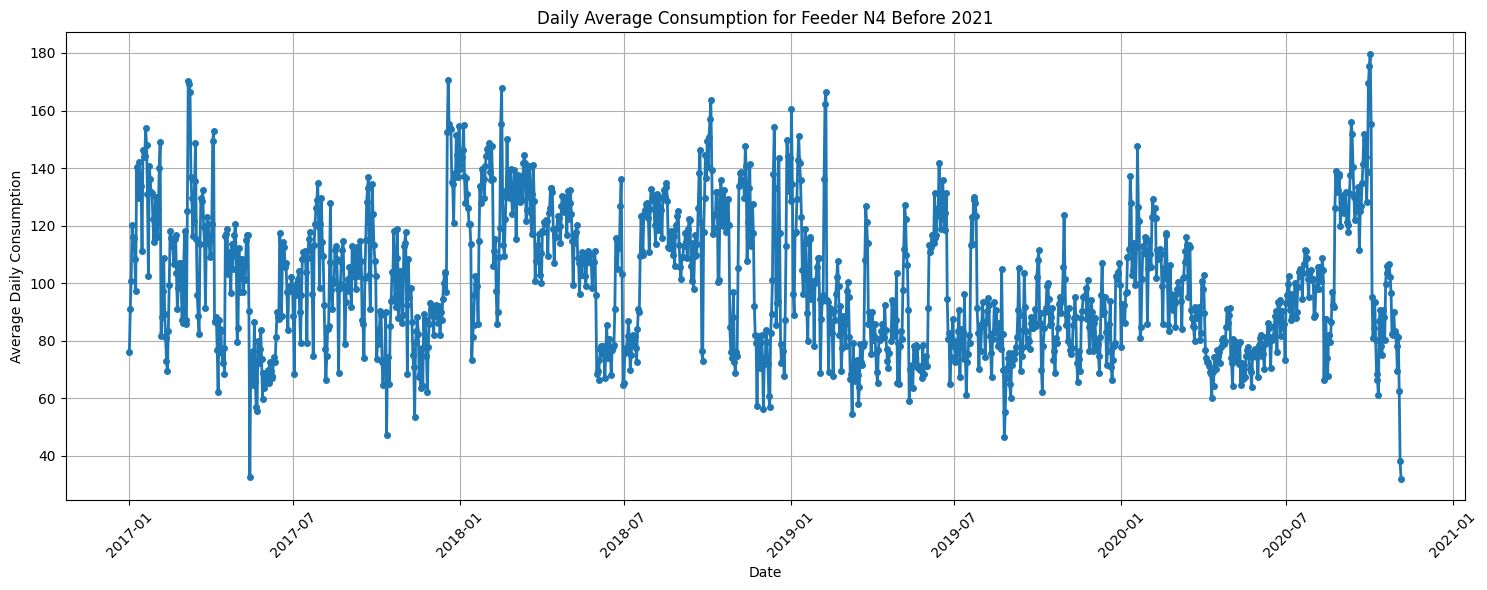

Daily averages from 2017-01 to 2020-12
Highest daily average: 179.78 in 2020-10-02
Lowest daily average: 32.00 in 2020-11-05


In [ ]:
# look at monthly average consumption for N4 before 2021 to check for patterns

df_N4 = df_consumption_filled[df_consumption_filled['feeder'] == 'N4'].copy()
df_N4['datetime'] = pd.to_datetime(df_N4['datetime'], errors='coerce')
df_N4 = df_N4.set_index('datetime').sort_index()

# Resample to Daily averages
df_N4_daily = df_N4.resample('D')['consumption'].mean()

plt.figure(figsize=(15, 6))
plt.plot(df_N4_daily.index, df_N4_daily.values, marker='o', linestyle='-', markersize=4, linewidth=2)
plt.title('Daily Average Consumption for Feeder N4')
plt.xlabel('Date')
plt.ylabel('Average Daily Consumption')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print some statistics
print(f"Daily averages from {df_N4_daily.index.min().strftime('%Y-%m')} to {df_N4_daily.index.max().strftime('%Y-%m')}")
print(f"Highest daily average: {df_N4_daily.max():.2f} in {df_N4_daily.idxmax().strftime('%Y-%m-%d')}")
print(f"Lowest daily average: {df_N4_daily.min():.2f} in {df_N4_daily.idxmin().strftime('%Y-%m-%d')}")

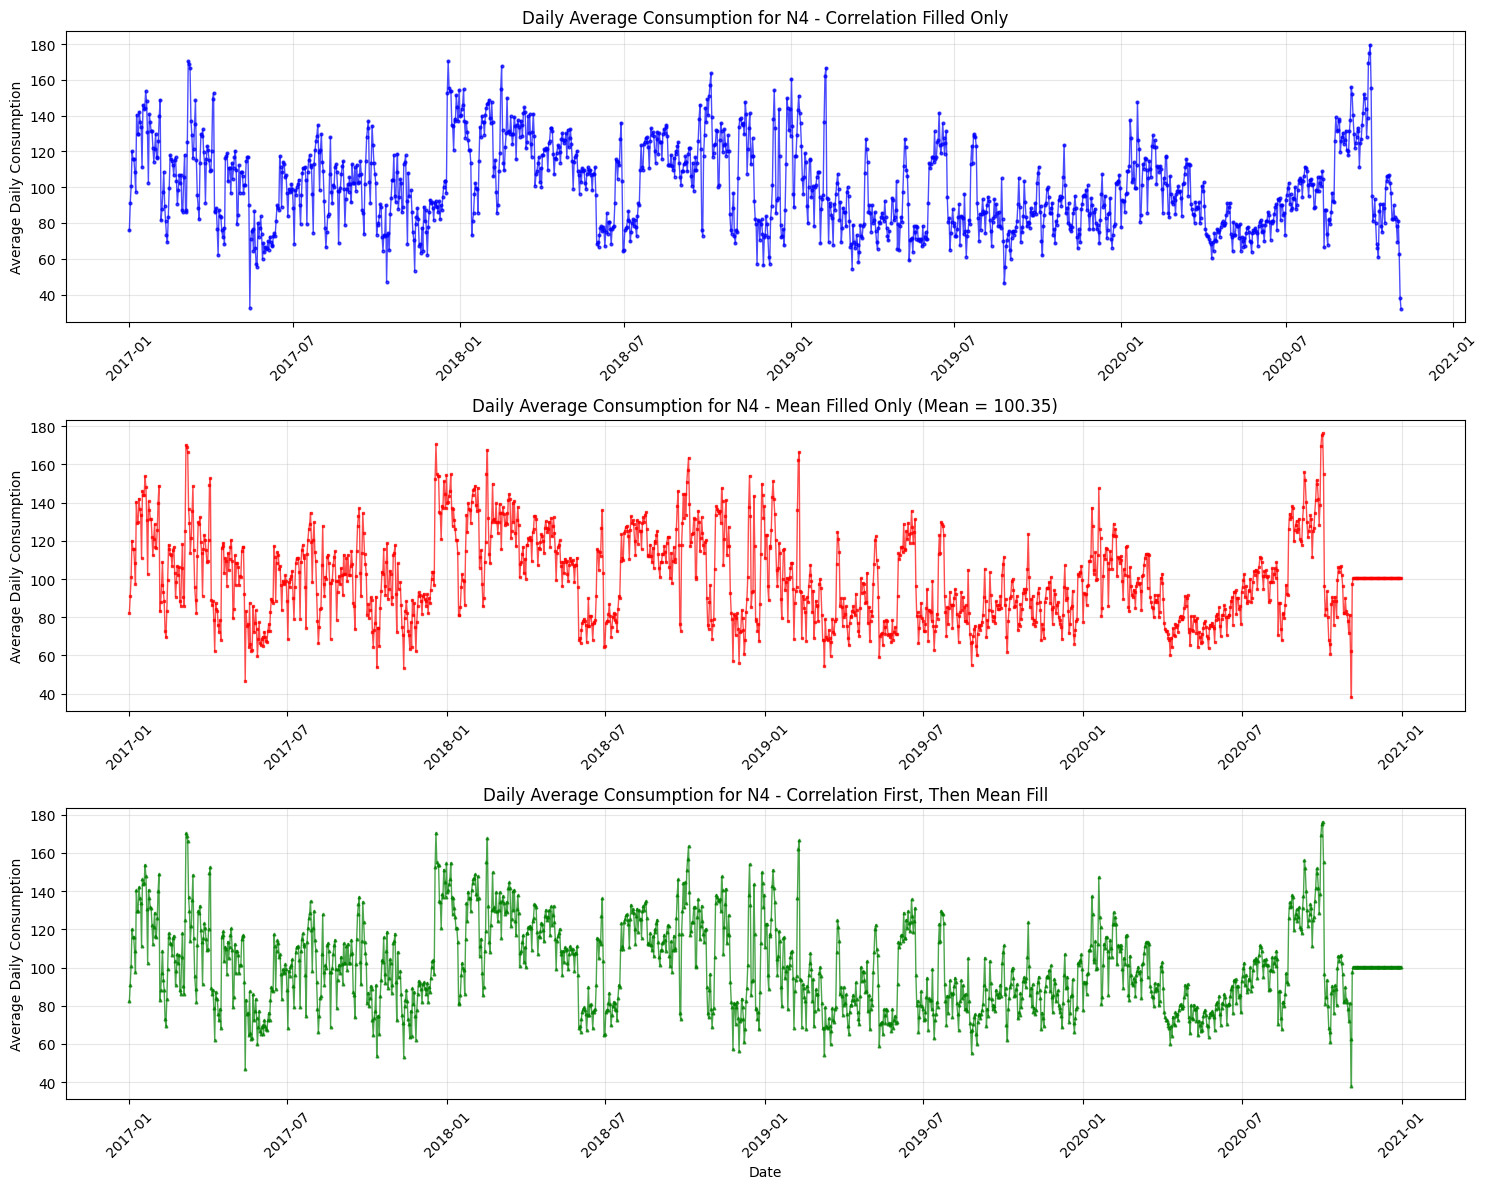

=== COMPARISON STATISTICS ===
N4 overall mean: 100.35

Correlation-filled daily stats:
  Mean: 100.12
  Std: 23.71
  Min: 32.00
  Max: 179.78

Mean-filled daily stats:
  Mean: 100.31
  Std: 22.69
  Min: 38.08
  Max: 176.47

Both methods combined daily stats:
  Mean: 100.31
  Std: 22.69
  Min: 38.08
  Max: 176.47

Standard deviation comparison:
  Correlation only: 23.71
  Mean only: 22.69
  Both methods: 22.69


In [38]:
# Compare N4 consumption: correlation-filled, mean-filled, and both methods combined

# Get N4 data from correlation-filled dataset
df_N4_corr_filled = df_consumption_filled[df_consumption_filled['feeder'] == 'N4'].copy()
df_N4_corr_filled['datetime'] = pd.to_datetime(df_N4_corr_filled['datetime'], errors='coerce')
df_N4_corr_filled = df_N4_corr_filled.set_index('datetime').sort_index()
df_N4_corr_filled_before_2021 = df_N4_corr_filled[df_N4_corr_filled.index < '2021-01-01']

# Get N4 data and fill missing values with mean
df_N4_mean_filled = pivot_df['N4'].copy()
n4_mean = df_N4_mean_filled.mean()
df_N4_mean_filled = df_N4_mean_filled.fillna(n4_mean)
df_N4_mean_filled.index = pd.to_datetime(df_N4_mean_filled.index, errors='coerce')
df_N4_mean_filled_before_2021 = df_N4_mean_filled[df_N4_mean_filled.index < '2021-01-01']

# Get N4 data and apply both methods: first correlation, then mean for remaining missing values
df_N4_both_filled = pivot_df['N4'].copy()
# First apply correlation filling (this was already done in pivot_df)
# Then apply mean filling to any remaining missing values
df_N4_both_filled = df_N4_both_filled.fillna(n4_mean)
df_N4_both_filled.index = pd.to_datetime(df_N4_both_filled.index, errors='coerce')
df_N4_both_filled_before_2021 = df_N4_both_filled[df_N4_both_filled.index < '2021-01-01']

# Resample all three to daily averages
df_N4_corr_daily = df_N4_corr_filled_before_2021.resample('D')['consumption'].mean()
df_N4_mean_daily = df_N4_mean_filled_before_2021.resample('D').mean()
df_N4_both_daily = df_N4_both_filled_before_2021.resample('D').mean()

# Create three subplot comparison
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Plot 1: Correlation filled
axes[0].plot(df_N4_corr_daily.index, df_N4_corr_daily.values, 
             marker='o', linestyle='-', markersize=2, linewidth=1, color='blue', alpha=0.7)
axes[0].set_title('Daily Average Consumption for N4 - Correlation Filled Only')
axes[0].set_ylabel('Average Daily Consumption')
axes[0].grid(True, alpha=0.3)

# Plot 2: Mean filled
axes[1].plot(df_N4_mean_daily.index, df_N4_mean_daily.values, 
             marker='s', linestyle='-', markersize=2, linewidth=1, color='red', alpha=0.7)
axes[1].set_title(f'Daily Average Consumption for N4 - Mean Filled Only (Mean = {n4_mean:.2f})')
axes[1].set_ylabel('Average Daily Consumption')
axes[1].grid(True, alpha=0.3)

# Plot 3: Both methods combined
axes[2].plot(df_N4_both_daily.index, df_N4_both_daily.values, 
             marker='^', linestyle='-', markersize=2, linewidth=1, color='green', alpha=0.7)
axes[2].set_title('Daily Average Consumption for N4 - Correlation First, Then Mean Fill')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Average Daily Consumption')
axes[2].grid(True, alpha=0.3)

# Format all x-axis labels
for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print comparison statistics for all three methods
print("=== COMPARISON STATISTICS ===")
print(f"N4 overall mean: {n4_mean:.2f}")

print(f"\nCorrelation-filled daily stats:")
print(f"  Mean: {df_N4_corr_daily.mean():.2f}")
print(f"  Std: {df_N4_corr_daily.std():.2f}")
print(f"  Min: {df_N4_corr_daily.min():.2f}")
print(f"  Max: {df_N4_corr_daily.max():.2f}")

print(f"\nMean-filled daily stats:")
print(f"  Mean: {df_N4_mean_daily.mean():.2f}")
print(f"  Std: {df_N4_mean_daily.std():.2f}")
print(f"  Min: {df_N4_mean_daily.min():.2f}")
print(f"  Max: {df_N4_mean_daily.max():.2f}")

print(f"\nBoth methods combined daily stats:")
print(f"  Mean: {df_N4_both_daily.mean():.2f}")
print(f"  Std: {df_N4_both_daily.std():.2f}")
print(f"  Min: {df_N4_both_daily.min():.2f}")
print(f"  Max: {df_N4_both_daily.max():.2f}")

print(f"\nStandard deviation comparison:")
print(f"  Correlation only: {df_N4_corr_daily.std():.2f}")
print(f"  Mean only: {df_N4_mean_daily.std():.2f}")
print(f"  Both methods: {df_N4_both_daily.std():.2f}")

## When filling in the mean fails
As we can see in the plotting of the mean values has a few weakpoints. For larger blocks of missing information, filling in the mean hurts the value of the data, and especially looking at the difference between the last period we see a stark difference.